# Лабораторна робота №1
## Інтерполяція кубічними сплайнами

**Мета:** вивчити метод інтерполяції кубічними сплайнами.

**Завдання:** за GPS-координатами маршруту від станції Заросляк до вершини Говерли отримати висоти,
побудувати гладкий профіль висоти маршруту кубічним сплайном (коефіцієнти $c_i$ — методом прогонки)
та проаналізувати складність маршруту.

На кожному відрізку $[x_{i-1}, x_i]$, $i = 1..n$, сплайн має вигляд
$$s_i(x) = a_i + b_i(x - x_{i-1}) + c_i(x - x_{i-1})^2 + d_i(x - x_{i-1})^3 .$$
Для вільного (природного) сплайна $c_1 = 0$, $c_{n+1} = 0$.

In [1]:
import json, os
import requests
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

### 1–2. Запит до Open-Elevation API

In [2]:
url = ("https://api.open-elevation.com/api/v1/lookup?locations="
       "48.164214,24.536044|48.164983,24.534836|48.165605,24.534068|48.166228,24.532915|"
       "48.166777,24.531927|48.167326,24.530884|48.167011,24.530061|48.166053,24.528039|"
       "48.166655,24.526064|48.166497,24.523574|48.166128,24.520214|48.165416,24.517170|"
       "48.164546,24.514640|48.163412,24.512980|48.162331,24.511715|48.162015,24.509462|"
       "48.162147,24.506932|48.161751,24.504244|48.161197,24.501793|48.160580,24.500537|"
       "48.160250,24.500106")

CACHE = "elevation_data.json"   # локальна копія на випадок, якщо API недоступне
try:
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    data = response.json()
    with open(CACHE, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=1)
    print("Дані отримано з API")
except Exception as e:
    print("API недоступне:", e, "- читаю кеш", CACHE)
    with open(CACHE, encoding="utf-8") as f:
        data = json.load(f)

results = data["results"]
n = len(results)
print("Кількість вузлів:", n)

Дані отримано з API
Кількість вузлів: 21


### 3. Табуляція вузлів (з записом у текстовий файл)

In [3]:
lines = ["№ | Latitude | Longitude | Elevation (m)"]
for i, point in enumerate(results):
    lines.append(f"{i:2d} | {point['latitude']:.6f} | {point['longitude']:.6f} | {point['elevation']:.2f}")

print("Табуляція вузлів:")
print("\n".join(lines))

with open("tabulation.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

Табуляція вузлів:
№ | Latitude | Longitude | Elevation (m)
 0 | 48.164214 | 24.536044 | 1269.42
 1 | 48.164983 | 24.534836 | 1293.43
 2 | 48.165605 | 24.534068 | 1293.43
 3 | 48.166228 | 24.532915 | 1325.24
 4 | 48.166777 | 24.531927 | 1316.99
 5 | 48.167326 | 24.530884 | 1323.59
 6 | 48.167011 | 24.530061 | 1323.59
 7 | 48.166053 | 24.528039 | 1346.29
 8 | 48.166655 | 24.526064 | 1376.77
 9 | 48.166497 | 24.523574 | 1413.13
10 | 48.166128 | 24.520214 | 1482.93
11 | 48.165416 | 24.517170 | 1521.99
12 | 48.164546 | 24.514640 | 1547.84
13 | 48.163412 | 24.512980 | 1625.94
14 | 48.162331 | 24.511715 | 1742.89
15 | 48.162015 | 24.509462 | 1787.37
16 | 48.162147 | 24.506932 | 1822.82
17 | 48.161751 | 24.504244 | 1883.61
18 | 48.161197 | 24.501793 | 1972.86
19 | 48.160580 | 24.500537 | 1972.86
20 | 48.160250 | 24.500106 | 2016.72


### 4. Кумулятивна відстань (формула гаверсинуса)

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2*R*np.arctan2(np.sqrt(a), np.sqrt(1-a))

coords = [(p["latitude"], p["longitude"]) for p in results]
elevations = [p["elevation"] for p in results]

distances = [0.0]
for i in range(1, n):
    d = haversine(*coords[i-1], *coords[i])
    distances.append(distances[-1] + d)

lines = ["№ | Distance (m) | Elevation (m)"]
for i in range(n):
    lines.append(f"{i:2d} | {distances[i]:10.2f} | {elevations[i]:8.2f}")
print("Табуляція (відстань, висота):")
print("\n".join(lines))

with open("tabulation.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "\n".join(lines) + "\n")

x_all = np.array(distances)
y_all = np.array(elevations)

Табуляція (відстань, висота):
№ | Distance (m) | Elevation (m)
 0 |       0.00 |  1269.42
 1 |     123.85 |  1293.43
 2 |     213.45 |  1293.43
 3 |     323.50 |  1325.24
 4 |     418.87 |  1316.99
 5 |     517.41 |  1323.59
 6 |     587.78 |  1323.59
 7 |     771.72 |  1346.29
 8 |     932.77 |  1376.77
 9 |    1118.27 |  1413.13
10 |    1370.81 |  1482.93
11 |    1610.05 |  1521.99
12 |    1821.16 |  1547.84
13 |    1997.39 |  1625.94
14 |    2149.88 |  1742.89
15 |    2320.63 |  1787.37
16 |    2508.86 |  1822.82
17 |    2713.03 |  1883.61
18 |    2904.98 |  1972.86
19 |    3020.67 |  1972.86
20 |    3069.34 |  2016.72


### 5. Графік дискретного профілю висоти

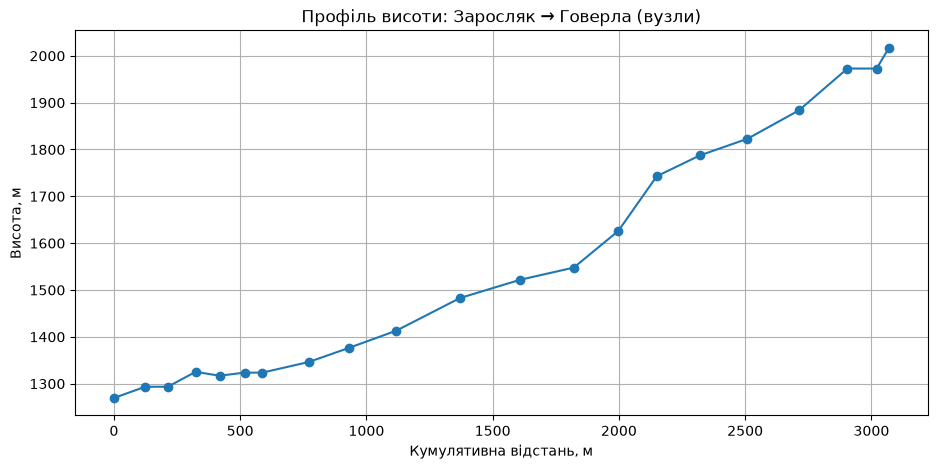

In [5]:
plt.plot(x_all, y_all, "o-", color="tab:blue")
plt.xlabel("Кумулятивна відстань, м")
plt.ylabel("Висота, м")
plt.title("Профіль висоти: Заросляк → Говерла (вузли)")
plt.show()

### 6. Система рівнянь для коефіцієнтів $c_i$

Позначимо $h_i = x_i - x_{i-1}$. Для $i = 2..n$:
$$h_{i-1}c_{i-1} + 2(h_{i-1}+h_i)c_i + h_i c_{i+1} = 3\left(\frac{y_i-y_{i-1}}{h_i} - \frac{y_{i-1}-y_{i-2}}{h_{i-1}}\right),$$
$c_1 = c_{n+1} = 0$. Отримуємо тридіагональну систему $n-1$ рівнянь виду
$\alpha_i c_{i-1} + \beta_i c_i + \gamma_i c_{i+1} = \delta_i$.

У коді використовується індексація Python з нуля: вузли $x_0..x_n$, невідомі $c_1..c_{n-1}$ (внутрішні вузли), $c_0 = c_n = 0$.

In [6]:
def build_system(x, y):
    # Коефіцієнти тридіагональної системи для c_1..c_{n-1} (n = кількість відрізків)
    x, y = np.asarray(x, float), np.asarray(y, float)
    h = np.diff(x)
    m = len(x) - 2                      # кількість невідомих
    alpha = np.zeros(m)                 # піддіагональ  (alpha[0] = 0)
    beta = np.zeros(m)                  # головна діагональ
    gamma = np.zeros(m)                 # наддіагональ  (gamma[-1] = 0)
    delta = np.zeros(m)                 # вільні члени
    for k in range(m):
        i = k + 1                       # номер внутрішнього вузла
        alpha[k] = h[i-1] if k > 0 else 0.0
        beta[k] = 2 * (h[i-1] + h[i])
        gamma[k] = h[i] if k < m - 1 else 0.0
        delta[k] = 3 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
    return h, alpha, beta, gamma, delta

h, alpha, beta, gamma, delta = build_system(x_all, y_all)
print(" k |    alpha    |    beta     |    gamma    |    delta")
for k in range(len(beta)):
    print(f"{k+1:2d} | {alpha[k]:11.4f} | {beta[k]:11.4f} | {gamma[k]:11.4f} | {delta[k]:11.6f}")

 k |    alpha    |    beta     |    gamma    |    delta
 1 |      0.0000 |    426.8953 |     89.5984 |   -0.581677
 2 |     89.5984 |    399.2982 |    110.0507 |    0.867234
 3 |    110.0507 |    410.8434 |     95.3710 |   -1.126989
 4 |     95.3710 |    387.8196 |     98.5388 |    0.460690
 5 |     98.5388 |    337.8215 |     70.3720 |   -0.200935
 6 |     70.3720 |    508.6301 |    183.9431 |    0.370260
 7 |    183.9431 |    689.9750 |    161.0444 |    0.197533
 8 |    161.0444 |    693.0901 |    185.5006 |    0.020308
 9 |    185.5006 |    876.0926 |    252.5456 |    0.241057
10 |    252.5456 |    983.5645 |    239.2366 |   -0.339378
11 |    239.2366 |    900.6912 |    211.1090 |   -0.122450
12 |    211.1090 |    774.6828 |    176.2324 |    0.962204
13 |    176.2324 |    657.4323 |    152.4837 |    0.971388
14 |    152.4837 |    646.4849 |    170.7587 |   -1.519469
15 |    170.7587 |    717.9633 |    188.2229 |   -0.216448
16 |    188.2229 |    784.7936 |    204.1739 |    0.328219


### 7. Метод прогонки

**Пряма прогонка:** шукаємо розв'язок у вигляді $c_i = A_i c_{i+1} + B_i$:
$$A_1 = -\frac{\gamma_1}{\beta_1},\quad B_1 = \frac{\delta_1}{\beta_1};\qquad
A_i = -\frac{\gamma_i}{\alpha_i A_{i-1} + \beta_i},\quad B_i = \frac{\delta_i - \alpha_i B_{i-1}}{\alpha_i A_{i-1} + \beta_i}.$$

**Зворотна прогонка:** $c_m = B_m$, далі $c_i = A_i c_{i+1} + B_i$ для $i = m-1, \dots, 1$.

Умова стійкості $|\beta_i| \ge |\alpha_i| + |\gamma_i|$ тут виконується строго, бо $2(h_{i-1}+h_i) > h_{i-1}+h_i$.

In [7]:
def thomas(alpha, beta, gamma, delta, verbose=False):
    m = len(beta)
    A = np.zeros(m); B = np.zeros(m)
    A[0] = -gamma[0] / beta[0]
    B[0] = delta[0] / beta[0]
    for i in range(1, m):
        denom = alpha[i] * A[i-1] + beta[i]
        A[i] = -gamma[i] / denom
        B[i] = (delta[i] - alpha[i] * B[i-1]) / denom
    x = np.zeros(m)
    x[-1] = B[-1]
    for i in range(m - 2, -1, -1):
        x[i] = A[i] * x[i+1] + B[i]
    if verbose:
        print("Прогонкові коефіцієнти:")
        print(" i |      A_i      |      B_i")
        for i in range(m):
            print(f"{i+1:2d} | {A[i]:13.8f} | {B[i]:13.8f}")
    return x

def check_stability(alpha, beta, gamma):
    return np.all(np.abs(beta) >= np.abs(alpha) + np.abs(gamma))

print("Умова діагональної переваги виконана:", check_stability(alpha, beta, gamma))
c_inner = thomas(alpha, beta, gamma, delta, verbose=True)

# Перевірка: обчислюємо ліву частину системи та порівнюємо з вектором вільних членів
M = np.diag(beta) + np.diag(alpha[1:], -1) + np.diag(gamma[:-1], 1)
residual = M @ c_inner - delta
print("\nМаксимальна нев'язка |Mc - delta|:", np.max(np.abs(residual)))

Умова діагональної переваги виконана: True
Прогонкові коефіцієнти:
 i |      A_i      |      B_i
 1 |   -0.20988373 |   -0.00136258
 2 |   -0.28923194 |    0.00260010
 3 |   -0.25162971 |   -0.00372845
 4 |   -0.27084391 |    0.00224362
 5 |   -0.22617972 |   -0.00135639
 6 |   -0.37332677 |    0.00094520
 7 |   -0.25920383 |    0.00003810
 8 |   -0.28479552 |    0.00002176
 9 |   -0.30676187 |    0.00028790
10 |   -0.26403094 |   -0.00045480
11 |   -0.25206280 |   -0.00001629
12 |   -0.24426850 |    0.00133844
13 |   -0.24818952 |    0.00119715
14 |   -0.28055781 |   -0.00279642
15 |   -0.28090644 |    0.00038962
16 |   -0.27895632 |    0.00034824
17 |   -0.26105019 |    0.00058550
18 |   -0.20470807 |   -0.00266681
19 |   -0.00000000 |    0.00987619

Максимальна нев'язка |Mc - delta|: 3.3306690738754696e-16


### 8–9. Коефіцієнти сплайнів $a_i, b_i, c_i, d_i$

$$a_i = y_{i-1},\qquad b_i = \frac{y_i - y_{i-1}}{h_i} - \frac{h_i}{3}(c_{i+1} + 2c_i),\qquad
d_i = \frac{c_{i+1} - c_i}{3h_i}.$$

In [8]:
def cubic_spline(x, y, verbose=False):
    x, y = np.asarray(x, float), np.asarray(y, float)
    h, alpha, beta, gamma, delta = build_system(x, y)
    c_full = np.zeros(len(x))
    c_full[1:-1] = thomas(alpha, beta, gamma, delta)
    a = y[:-1].copy()
    c = c_full[:-1].copy()
    b = (y[1:] - y[:-1]) / h - h * (c_full[1:] + 2 * c_full[:-1]) / 3
    d = (c_full[1:] - c_full[:-1]) / (3 * h)
    if verbose:
        print(" i |   [x_{i-1}, x_i], м   |     a_i     |      b_i      |      c_i       |      d_i")
        for i in range(len(h)):
            print(f"{i+1:2d} | [{x[i]:7.1f}, {x[i+1]:7.1f}] | {a[i]:11.4f} | {b[i]:13.8f} | "
                  f"{c[i]:14.10f} | {d[i]:15.12f}")
    return a, b, c, d

def spline_eval(x_nodes, coeffs, xx):
    a, b, c, d = coeffs
    x_nodes = np.asarray(x_nodes, float)
    idx = np.clip(np.searchsorted(x_nodes, xx, side="right") - 1, 0, len(a) - 1)
    t = xx - x_nodes[idx]
    return a[idx] + b[idx]*t + c[idx]*t**2 + d[idx]*t**3

def spline_deriv(x_nodes, coeffs, xx):
    a, b, c, d = coeffs
    x_nodes = np.asarray(x_nodes, float)
    idx = np.clip(np.searchsorted(x_nodes, xx, side="right") - 1, 0, len(a) - 1)
    t = xx - x_nodes[idx]
    return b[idx] + 2*c[idx]*t + 3*d[idx]*t**2

coeffs_full = cubic_spline(x_all, y_all, verbose=True)

 i |   [x_{i-1}, x_i], м   |     a_i     |      b_i      |      c_i       |      d_i
 1 | [    0.0,   123.8] |   1269.4177 |    0.28369856 |   0.0000000000 | -0.000005854899
 2 | [  123.8,   213.4] |   1293.4312 |    0.01427993 |  -0.0021753750 |  0.000022500383
 3 | [  213.4,   323.5] |   1293.4312 |    0.16635022 |   0.0038726187 | -0.000025055960
 4 | [  323.5,   418.9] |   1325.2444 |    0.10834894 |  -0.0043996600 |  0.000024700450
 5 | [  418.9,   517.4] |   1316.9867 |   -0.05685282 |   0.0026674585 | -0.000014317034
 6 | [  517.4,   587.8] |   1323.5867 |    0.05179274 |  -0.0015648924 |  0.000011778937
 7 | [  587.8,   771.7] |   1323.5867 |    0.00653904 |   0.0009218279 | -0.000001557049
 8 | [  771.7,   932.8] |   1346.2889 |    0.18761824 |   0.0000626025 | -0.000000325255
 9 | [  932.8,  1118.3] |   1376.7689 |    0.18247507 |  -0.0000945389 |  0.000000903668
10 | [ 1118.3,  1370.8] |   1413.1333 |    0.24068803 |   0.0004083543 | -0.000001057243
11 | [ 1370.8,  1610.1] |

Перевірка: сплайн проходить через усі вузли, а результат збігається з `scipy.interpolate.CubicSpline` (natural).

In [9]:
print("Макс. відхилення у вузлах:", np.max(np.abs(spline_eval(x_all, coeffs_full, x_all) - y_all)))
try:
    from scipy.interpolate import CubicSpline
    xx_chk = np.linspace(x_all[0], x_all[-1], 2000)
    ref = CubicSpline(x_all, y_all, bc_type="natural")(xx_chk)
    print("Макс. розбіжність зі SciPy:", np.max(np.abs(ref - spline_eval(x_all, coeffs_full, xx_chk))))
except ImportError:
    print("SciPy не встановлено — перевірку пропущено")

Макс. відхилення у вузлах: 2.2737367544323206e-13
SciPy не встановлено — перевірку пропущено


### 10. Сплайни з 10, 15 та 20 вузлами


===== 10 вузлів =====
 i |   [x_{i-1}, x_i], м   |     a_i     |      b_i      |      c_i       |      d_i
 1 | [    0.0,   213.4] |   1269.4177 |    0.10870968 |   0.0000000000 |  0.000000083252
 2 | [  213.4,   418.9] |   1293.4312 |    0.12008860 |   0.0000533101 | -0.000000387943
 3 | [  418.9,   771.7] |   1316.9867 |    0.09287936 |  -0.0001857657 |  0.000000447468
 4 | [  771.7,  1118.3] |   1346.2889 |    0.12892015 |   0.0002879065 | -0.000000298141
 5 | [ 1118.3,  1610.1] |   1413.1333 |    0.22105093 |  -0.0000220514 |  0.000000046091
 6 | [ 1610.1,  1997.4] |   1521.9911 |    0.23280349 |   0.0000459493 |  0.000000118436
 7 | [ 1997.4,  2508.9] |   1625.9423 |    0.32170775 |   0.0001835750 | -0.000000117229
 8 | [ 2508.9,  2905.0] |   1822.8223 |    0.41749182 |   0.0000036988 | -0.000000256159
 9 | [ 2905.0,  3069.3] |   1972.8578 |    0.29983954 |  -0.0003007105 |  0.000000609850

===== 15 вузлів =====
 i |   [x_{i-1}, x_i], м   |     a_i     |      b_i      |      c_i 

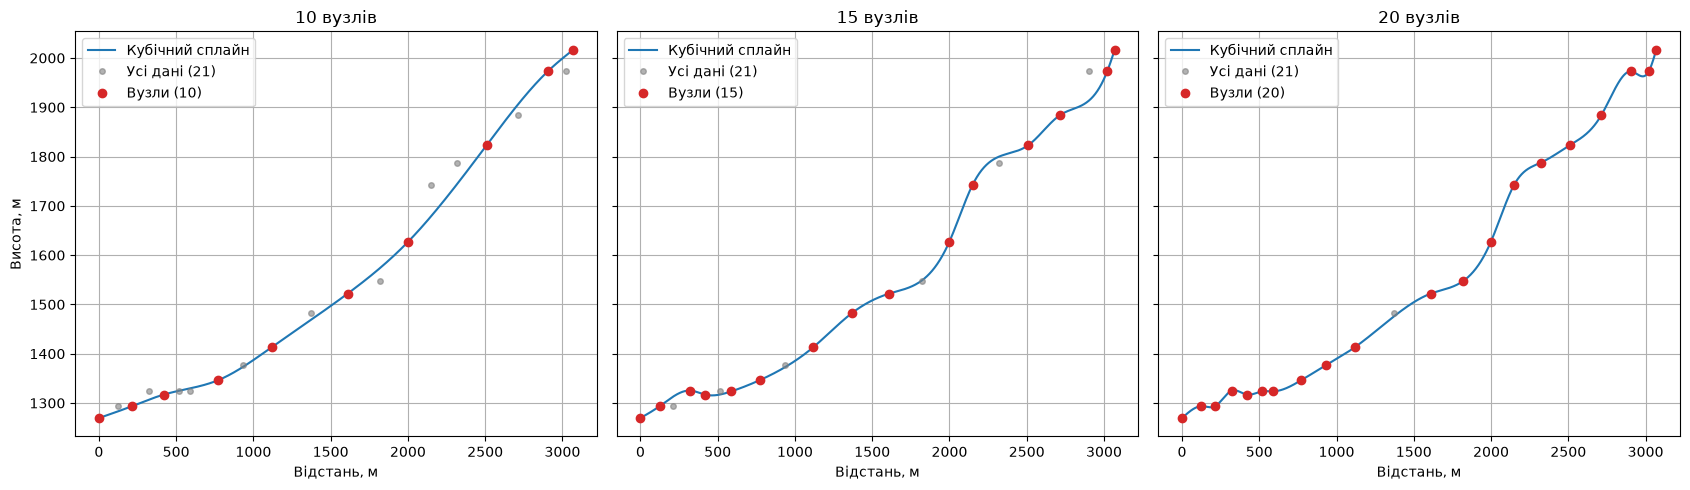

In [10]:
xx = np.linspace(x_all[0], x_all[-1], 2000)

def pick_nodes(k):
    # k рівномірно розподілених індексів з усіх вузлів (перший і останній завжди включені)
    idx = np.unique(np.round(np.linspace(0, n - 1, k)).astype(int))
    return x_all[idx], y_all[idx]

node_counts = [10, 15, 20]
splines = {}
for k in node_counts:
    xk, yk = pick_nodes(k)
    print(f"\n===== {k} вузлів =====")
    splines[k] = (xk, yk, cubic_spline(xk, yk, verbose=True))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, k in zip(axes, node_counts):
    xk, yk, cf = splines[k]
    ax.plot(xx, spline_eval(xk, cf, xx), label="Кубічний сплайн")
    ax.plot(x_all, y_all, "o", ms=4, color="gray", alpha=0.6, label=f"Усі дані ({n})")
    ax.plot(xk, yk, "o", color="tab:red", label=f"Вузли ({k})")
    ax.set_title(f"{k} вузлів")
    ax.set_xlabel("Відстань, м")
    ax.legend()
axes[0].set_ylabel("Висота, м")
plt.tight_layout()
plt.show()

### 11–12. Вплив кількості вузлів на точність

За «задану функцію» $f(x)$ беремо сплайн, побудований за всіма 21 вузлами (найповніші дані),
а $\varphi(x)$ — сплайн за 10, 15 або 20 вузлами. Похибка $\varepsilon(x) = |f(x) - \varphi(x)|$
обчислюється на всьому відрізку $[x_0, x_n]$. Додатково рахуємо похибку у «викинутих» вузлах —
там відоме справжнє значення висоти з API.

 Вузлів | max ε(x), м | середня ε(x), м | max похибка у пропущених вузлах, м
    10  |      67.551 |          14.395 |     64.043
    15  |      62.358 |           6.399 |     58.630
    20  |       7.397 |           0.735 |      7.395


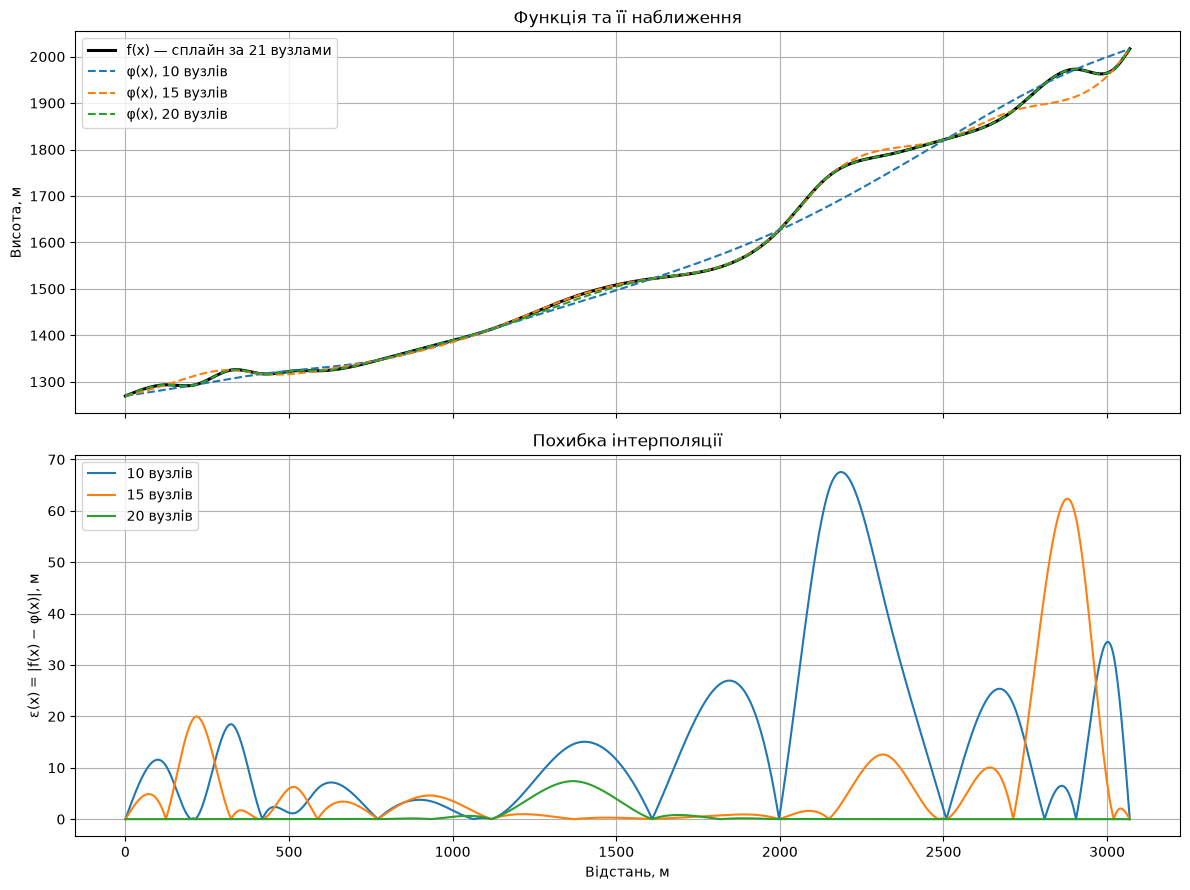

In [11]:
f_ref = spline_eval(x_all, coeffs_full, xx)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
axes[0].plot(xx, f_ref, "k", lw=2.2, label=f"f(x) — сплайн за {n} вузлами")
print(" Вузлів | max ε(x), м | середня ε(x), м | max похибка у пропущених вузлах, м")
for k in node_counts:
    xk, yk, cf = splines[k]
    phi = spline_eval(xk, cf, xx)
    err = np.abs(f_ref - phi)
    axes[0].plot(xx, phi, "--", label=f"φ(x), {k} вузлів")
    axes[1].plot(xx, err, label=f"{k} вузлів")
    missing = ~np.isin(x_all, xk)
    node_err = np.max(np.abs(spline_eval(xk, cf, x_all[missing]) - y_all[missing])) if missing.any() else 0.0
    print(f"   {k:3d}  | {err.max():11.3f} | {err.mean():15.3f} | {node_err:10.3f}")
axes[0].set_ylabel("Висота, м"); axes[0].legend(); axes[0].set_title("Функція та її наближення")
axes[1].set_ylabel("ε(x) = |f(x) − φ(x)|, м"); axes[1].set_xlabel("Відстань, м")
axes[1].legend(); axes[1].set_title("Похибка інтерполяції")
plt.tight_layout()
plt.show()

### Додатково 1. Характеристики маршруту

In [12]:
print("Загальна довжина маршруту (м):", round(distances[-1], 2))
total_ascent = sum(max(elevations[i] - elevations[i-1], 0) for i in range(1, n))
total_descent = sum(max(elevations[i-1] - elevations[i], 0) for i in range(1, n))
print("Сумарний набір висоти (м):", round(total_ascent, 2))
print("Сумарний спуск (м):", round(total_descent, 2))

Загальна довжина маршруту (м): 3069.34
Сумарний набір висоти (м): 755.56
Сумарний спуск (м): 8.26


### Додатково 2. Аналіз градієнта (через похідну сплайна)

Максимальний підйом (%): 106.14
Максимальний спуск (%): -19.38
Середній градієнт (%): 25.81
Розбіжність np.gradient та аналітичної похідної (%): 0.0159

Ділянки з крутизною > 15%:
      0.0 –    86.0 м (довжина   86.0 м), макс. 28.4%
    211.9 –   317.8 м (довжина  105.9 м), макс. 36.6%
    377.7 –   388.5 м (довжина   10.7 м), макс. -15.3%
    695.6 –  1506.3 м (довжина  810.7 м), макс. 29.3%
   1768.8 –  2269.4 м (довжина  500.6 м), макс. 83.6%
   2329.3 –  2885.1 м (довжина  555.8 м), макс. 63.0%
   2925.0 –  2960.3 м (довжина   35.3 м), макс. -19.4%
   2995.6 –  3069.3 м (довжина   73.7 м), макс. 106.1%
Частка маршруту з крутизною > 15%: 71.4%


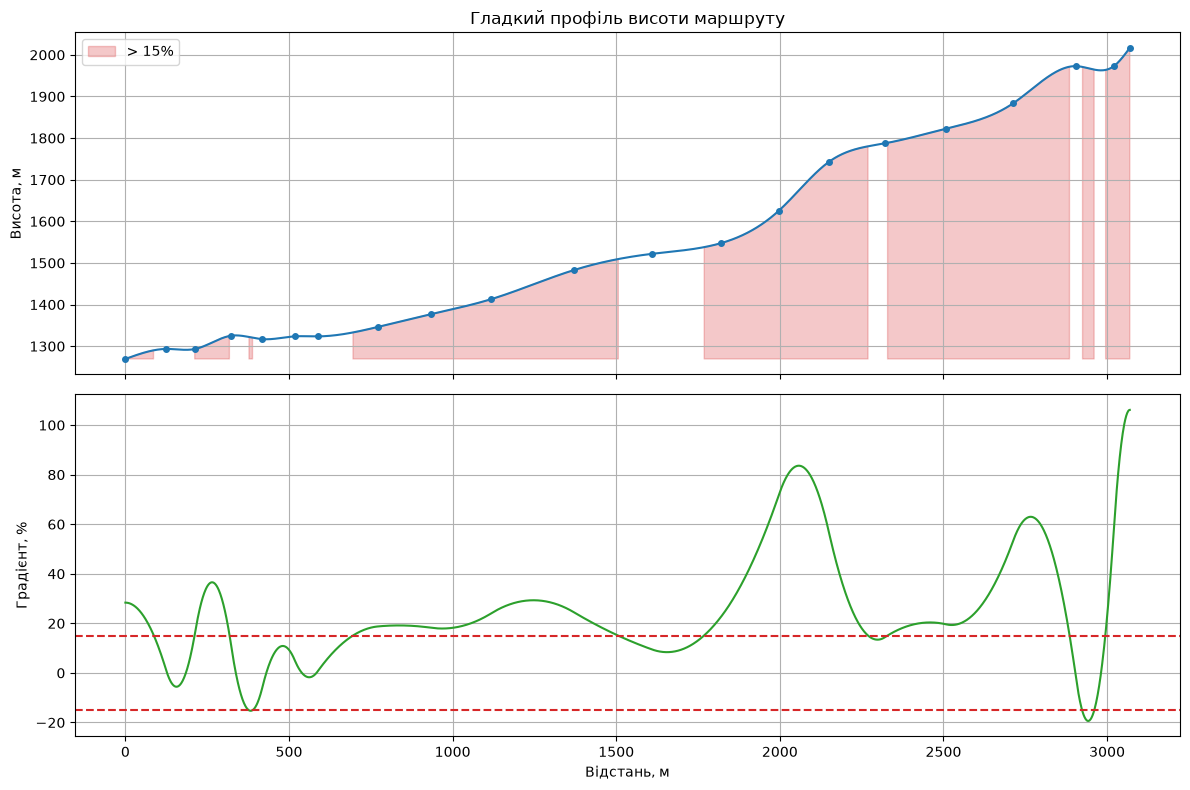

In [13]:
yy_full = spline_eval(x_all, coeffs_full, xx)
grad_full = np.gradient(yy_full, xx) * 100
grad_exact = spline_deriv(x_all, coeffs_full, xx) * 100   # аналітична похідна сплайна

print("Максимальний підйом (%):", round(np.max(grad_full), 2))
print("Максимальний спуск (%):", round(np.min(grad_full), 2))
print("Середній градієнт (%):", round(np.mean(np.abs(grad_full)), 2))
print("Розбіжність np.gradient та аналітичної похідної (%):", np.max(np.abs(grad_full - grad_exact)).round(4))

steep = np.abs(grad_full) > 15
edges = np.flatnonzero(np.diff(np.r_[0, steep.astype(int), 0]))
print("\nДілянки з крутизною > 15%:")
for s, e in zip(edges[::2], edges[1::2]):
    seg = grad_full[s:e]
    print(f"  {xx[s]:7.1f} – {xx[e-1]:7.1f} м (довжина {xx[e-1]-xx[s]:6.1f} м), "
          f"макс. {seg[np.argmax(np.abs(seg))]:.1f}%")
print(f"Частка маршруту з крутизною > 15%: {steep.mean()*100:.1f}%")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(xx, yy_full)
axes[0].fill_between(xx, yy_full.min(), yy_full, where=steep, color="tab:red", alpha=0.25, label="> 15%")
axes[0].plot(x_all, y_all, "o", color="tab:blue", ms=4)
axes[0].set_ylabel("Висота, м"); axes[0].legend(); axes[0].set_title("Гладкий профіль висоти маршруту")
axes[1].plot(xx, grad_full, color="tab:green")
axes[1].axhline(15, color="tab:red", ls="--"); axes[1].axhline(-15, color="tab:red", ls="--")
axes[1].set_ylabel("Градієнт, %"); axes[1].set_xlabel("Відстань, м")
plt.tight_layout()
plt.show()

### Додатково 3. Механічна енергія підйому (маса 80 кг)

In [14]:
mass = 80
g = 9.81
energy = mass * g * total_ascent
print("Механічна робота (Дж):", round(energy, 1))
print("Механічна робота (кДж):", round(energy / 1000, 2))
print("Енергія (ккал):", round(energy / 4184, 2))

Механічна робота (Дж): 592967.0
Механічна робота (кДж): 592.97
Енергія (ккал): 141.72


### Висновки

- Маршрут Заросляк → Говерла має довжину ≈ 3,07 км (по прямих між вузлами) і набір висоти ≈ 756 м
  (1269 → 2017 м) при сумарному спуску лише ≈ 8 м. Середній модуль градієнта ≈ 26%, понад 70% маршруту
  крутіше за 15%, отже маршрут складний. Робота проти сили тяжіння для 80 кг ≈ 593 кДж (≈ 142 ккал).
- Пікові значення градієнта сплайна (≈ 100% на останніх ~50 м) — це наслідок різкої зміни висоти між
  близькими вузлами (+44 м на 49 м) і коливання сплайна; реальний ухил на коротких ділянках потрібно
  оцінювати обережно.
- Кубічний сплайн проходить через усі вузли і має неперервні першу та другу похідні, тому дає гладкий профіль,
  на основі якого коректно оцінюється градієнт (ламана дає лише кусково-сталий ухил).
- Система для коефіцієнтів $c_i$ тридіагональна з діагональною перевагою, тому метод прогонки стійкий
  і розв'язує її за $O(n)$ операцій; нев'язка розв'язку ≈ $10^{-16}$, тобто на рівні похибки округлення,
  а сплайн проходить через усі вузли з точністю ≈ $10^{-13}$ м.
- **Вплив кількості вузлів:** зі зменшенням кількості вузлів похибка зростає. При 20 вузлах (пропущено лише
  вузол 10) максимальна похибка ≈ 7 м, середня < 1 м. При 15 вузлах середня похибка ≈ 6 м, але максимальна
  ≈ 62 м — пропущено вузол 18 перед плато під вершиною (1884 → 1973 м), і сплайн не «знає» про різкий підйом.
  При 10 вузлах середня похибка ≈ 14 м, максимальна ≈ 68 м: сплайн згладжує локальні перегини рельєфу.
  Отже, середня похибка стабільно зменшується зі збільшенням кількості вузлів, а максимальна залежить від того,
  чи потрапили у вибірку вузли в місцях різкої зміни рельєфу. Для реальних геоданих точність визначається
  щільністю та розташуванням вузлів — сплайн не може відтворити форму рельєфу, якої немає в даних.

### Контрольні питання

1. **Табуляція** — обчислення значень функції на наборі точок (вузлів) аргументу та подання їх у вигляді таблиці.
2. **Інтерполяція** — побудова функції $\varphi(x)$, яка в заданих вузлах $x_i$ набуває заданих значень $y_i$,
   і використання її для наближеного обчислення значень між вузлами.
3. **Кубічний сплайн** — кусково-поліноміальна функція, яка на кожному відрізку $[x_{i-1}, x_i]$ є многочленом
   третього степеня, проходить через усі вузли та має неперервні першу і другу похідні на всьому відрізку.
   Фізично — форма гнучкого пружного стрижня, що мінімізує потенціальну енергію згину.
4. Система $4n$ лінійних рівнянь: $2n$ умов проходження через вузли, $2(n-1)$ умов неперервності першої та другої
   похідних, 2 крайові умови (для вільного сплайна $s''(x_0)=s''(x_n)=0$). Після виключення $a_i, b_i, d_i$
   вона зводиться до тридіагональної системи відносно $c_i$.
5. **Метод прогонки** — спеціалізований метод Гауса для систем з тридіагональною матрицею: пряма прогонка
   обчислює коефіцієнти $A_i, B_i$ у співвідношенні $c_i = A_i c_{i+1} + B_i$, зворотна — послідовно знаходить невідомі
   від останньої до першої. Складність $O(n)$; стійкий за умови $|\beta_i| \ge |\alpha_i| + |\gamma_i|$.
6. Для достатньо гладкої функції похибка кубічного сплайна має порядок $O(h^4)$ (для самої функції),
   $O(h^3)$ — для першої похідної, $O(h^2)$ — для другої, де $h = \max h_i$.
7. На кожному відрізку визначаються $a_i, b_i, c_i, d_i$: $a_i = y_{i-1}$; $c_i$ — з тридіагональної системи методом
   прогонки ($c_1 = c_{n+1} = 0$); $b_i = \frac{y_i - y_{i-1}}{h_i} - \frac{h_i}{3}(c_{i+1} + 2c_i)$;
   $d_i = \frac{c_{i+1} - c_i}{3h_i}$.